# Задание 6. Возведение матрицы переходов в степень и предельное распределение

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# матрица переходов из задания 5
bases = ['A', 'C', 'G', 'T']
P = np.array([
    [0.3312, 0.1724, 0.2347, 0.2616],
    [0.3570, 0.2496, 0.0565, 0.3369],
    [0.2942, 0.2074, 0.2507, 0.2477],
    [0.2162, 0.2022, 0.2468, 0.3347]
])

Возведение в степень и вывод матриц

In [3]:
for k in [1, 2, 5, 10, 50, 100]:
    Pk = np.linalg.matrix_power(P, k)
    print(f"P^{k}:")
    print(pd.DataFrame(Pk, index=bases, columns=bases).round(4))
    print()

P^1:
        A       C       G       T
A  0.3312  0.1724  0.2347  0.2616
C  0.3570  0.2496  0.0565  0.3369
G  0.2942  0.2074  0.2507  0.2477
T  0.2162  0.2022  0.2468  0.3347

P^2:
        A       C       G       T
A  0.2968  0.2017  0.2109  0.2904
C  0.2968  0.2037  0.1952  0.3042
G  0.2988  0.2046  0.2047  0.2918
T  0.2888  0.2066  0.2066  0.2978

P^5:
        A       C       G       T
A  0.2948  0.2041  0.2051  0.2957
C  0.2948  0.2041  0.2051  0.2957
G  0.2948  0.2041  0.2051  0.2957
T  0.2948  0.2041  0.2051  0.2957

P^10:
        A       C       G       T
A  0.2947  0.2040  0.2051  0.2956
C  0.2947  0.2041  0.2051  0.2956
G  0.2947  0.2041  0.2051  0.2956
T  0.2947  0.2040  0.2051  0.2956

P^50:
       A       C       G       T
A  0.294  0.2036  0.2046  0.2949
C  0.294  0.2036  0.2046  0.2949
G  0.294  0.2036  0.2046  0.2949
T  0.294  0.2036  0.2046  0.2949

P^100:
        A      C      G      T
A  0.2931  0.203  0.204  0.294
C  0.2932  0.203  0.204  0.294
G  0.2932  0.203  0.204

График стабилизации матрицы

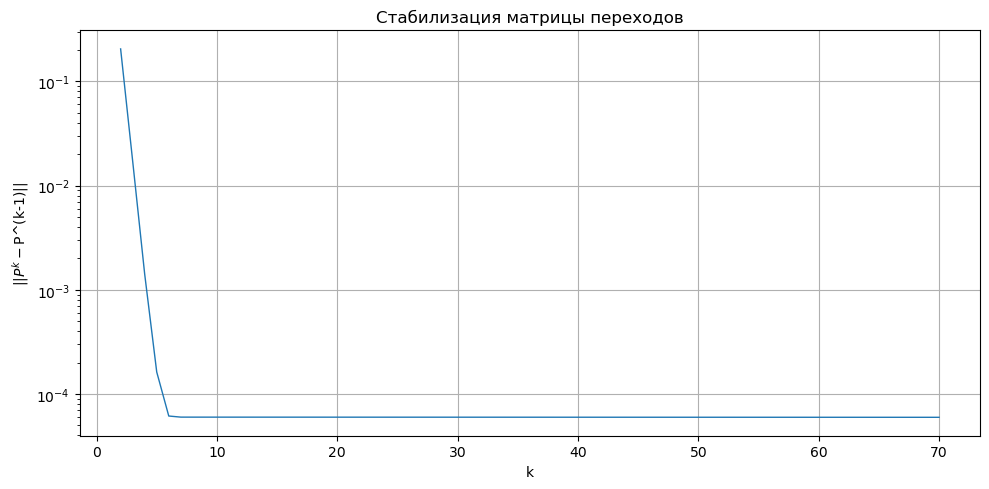

In [12]:
norms = []
K = 70

P_prev = P.copy()
for k in range(2, K + 1):
    P_k = np.linalg.matrix_power(P, k)
    norms.append(np.linalg.norm(P_k - P_prev, 'fro'))
    P_prev = P_k

plt.figure(figsize=(10, 5))
plt.plot(range(2, K + 1), norms, linewidth=1)
plt.xlabel("k")
plt.ylabel("$||P^k - $P^(k-1)$||$")
plt.title("Стабилизация матрицы переходов")
plt.yscale('log')
plt.grid(True)
plt.tight_layout()
plt.show()

Проверка сходимости к стационарному распределению

In [15]:
P1000 = np.linalg.matrix_power(P, 1000)

print("P^1000:")
print(pd.DataFrame(P1000, index=bases, columns=bases).round(6))

eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary = np.real(eigenvectors[:, idx])
stationary = stationary / stationary.sum()

print("\nСтационарное распределение π:")
for b, p in zip(bases, stationary):
    print(f"  pi({b}) = {p:.6f}")

P^1000:
          A         C         G         T
A  0.277956  0.192451  0.193414  0.278785
C  0.277981  0.192468  0.193431  0.278809
G  0.277985  0.192471  0.193435  0.278814
T  0.277958  0.192452  0.193415  0.278786

Стационарное распределение π:
  pi(A) = 0.294881
  pi(C) = 0.204169
  pi(G) = 0.205191
  pi(T) = 0.295759
